In [1]:
import torch.nn as nn
import torch 
import torch.optim as optim 
import matplotlib.pyplot as plt 

In [2]:
torch.manual_seed(42)
#fuck me bruh randn not random 
x = torch.randn(200,2)
y = (x[:,0] + x[:,1]>0).float().view(-1,1) 

In [ ]:
class SimpleNN(nn.Module): 
    def __init__(self, a_fn): 
        super().__init__()
        self.fc1 = nn.Linear(2,8)
        self.fc2 = nn.Linear(8,1)
        self.a = a_fn 
    
    def forward(self, x): 
        x = self.a(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x 

def train(l_r, a_fn, epochs = 50):
    model = SimpleNN(a_fn)
    cr = nn.BCELoss() 
    #dont forget to pass lr here in opt 
    opt = optim.SGD(model.parameters(), lr=l_r)
    losses = []
    
    for _ in range(epochs): 
        opt.zero_grad()
        
        ops = model(x)
        loss = cr(ops, y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
        
    return losses
    

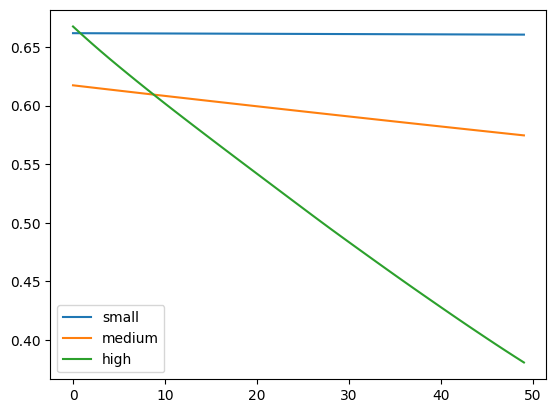

In [ ]:
plt.figure()
plt.plot(train(0.001, nn.ReLU()), label='small')
plt.plot(train(0.01, nn.ReLU()), label='medium')
plt.plot(train(0.1, nn.ReLU()), label='high')
plt.legend()
plt.show()

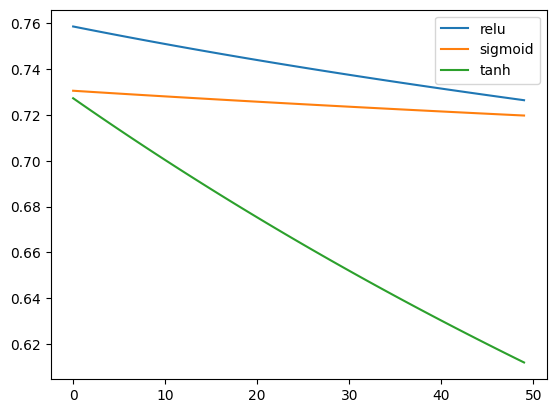

In [5]:
plt.figure()
plt.plot(train(0.01, nn.ReLU()), label='relu')
plt.plot(train(0.01, nn.Sigmoid()), label='sigmoid')
plt.plot(train(0.01, nn.Tanh()), label='tanh')
plt.legend()
plt.show()